# Debug MPI code

### Tiled grid test

Tests `grid::flat<>` class:

+ `grid::flat<>` object creation
+ `.set()` method
+ `.copy_to_gc()` and `.add_to_gc()` methods
+ `.x_shift_left()` method
+ `.kernel3_x()` and `.kernel3_y()` methods
+ `.save()` method

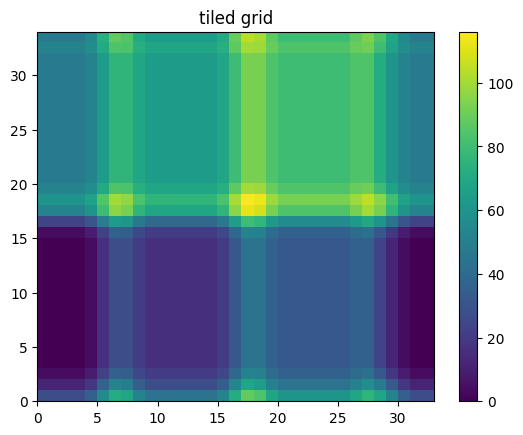

In [1]:
import visxd
visxd.grid( "mpi/mpi.zdf" )

### Vector field grid test

Tests `grid::vec3_tiled<>` class:

+ Same tests as the `tiled<>` class except...
+ `.save()` method for each vector component

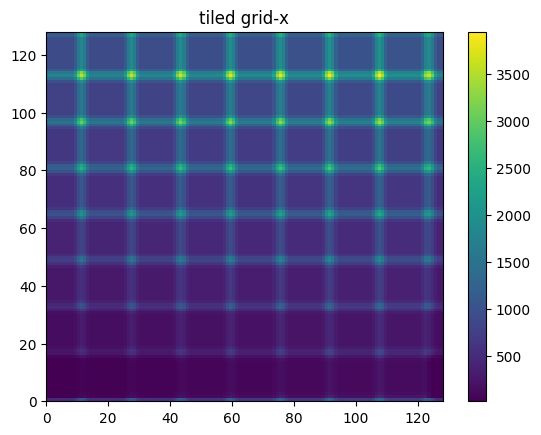

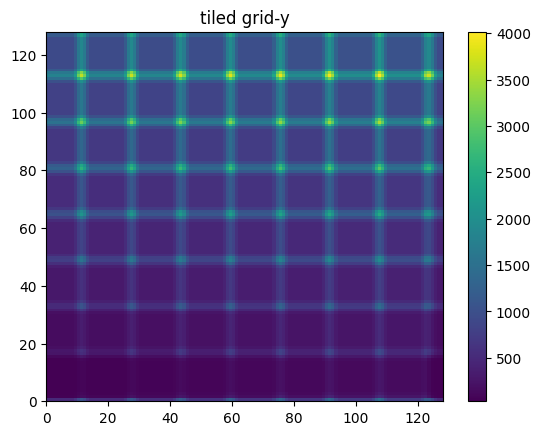

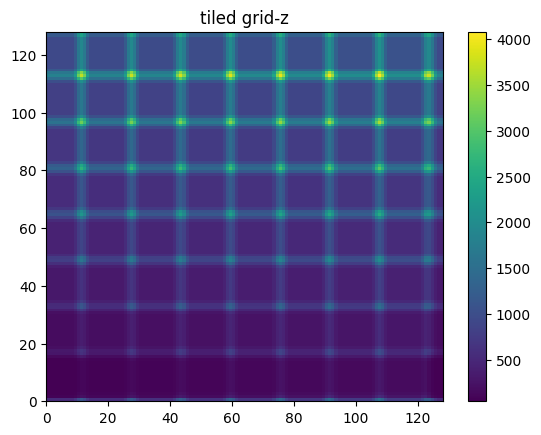

In [4]:
import visxd

visxd.grid("mpi/mpi-vec3-x.zdf" )
visxd.grid("mpi/mpi-vec3-y.zdf" )
visxd.grid("mpi/mpi-vec3-z.zdf" )

### Ghosted grid test

Tests `grid::flat<>` class:

+ `grid::flat<>` object creation
+ `.set()` method
+ `.copy_to_gc()` and `.add_to_gc()` methods
+ `.x_shift_left()` method
+ `.kernel3_x()` and `.kernel3_y()` methods
+ `.save()` method

make: Nothing to be done for `all'.
MPI running on 4 processes
SIMD support not enabled
OpenMP enabled
  # procs           : 14
  max_threads       : 14
  default # threads : 14
Running test_ghosted()...
[0] local dims: (512, 256)
[1] local dims: (512, 256)
[2] local dims: (512, 256)
[3] local dims: (512, 256)
[1] local pos: (0, 256)
[0] local pos: (0, 0)
Setting values...
[2] local pos: (512, 0)
[3] local pos: (512, 256)
Saving data...
Done!


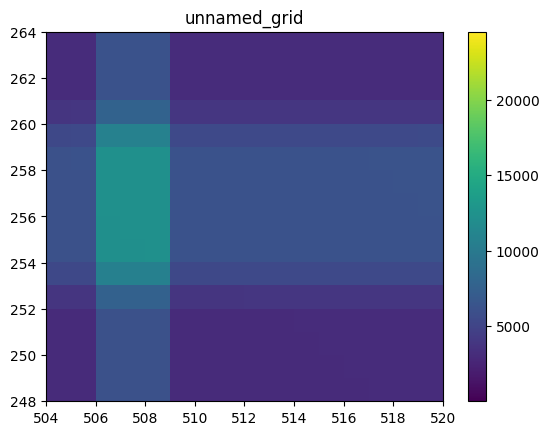

In [5]:
! make -j 12 && mpirun -np 4 ./zpic

import visxd
# visxd.grid( "mpi/mpi.zdf" )
visxd.grid( "mpi/mpi.zdf", xlim = [512-8, 512+8], ylim = [256-8, 256+8] )

### Flat grid test


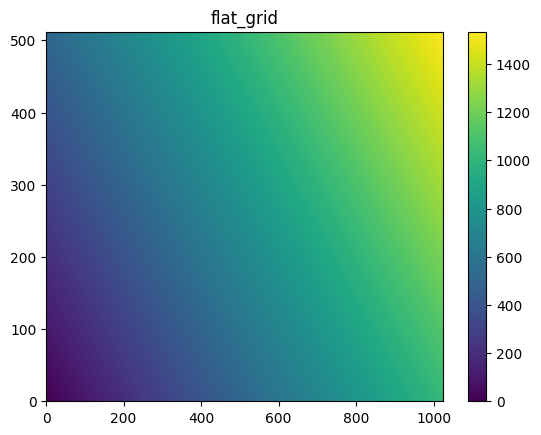

In [6]:
import visxd
visxd.grid( "mpi/mpi.zdf" )

## FFT tests

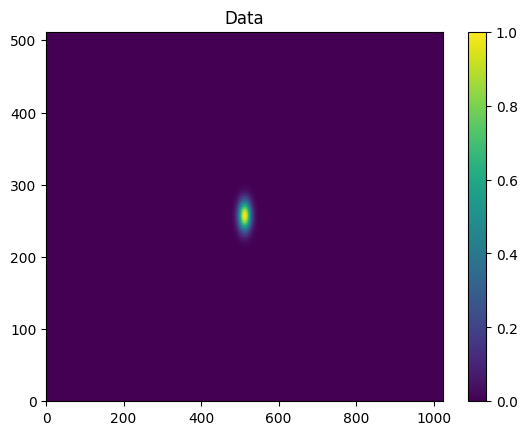

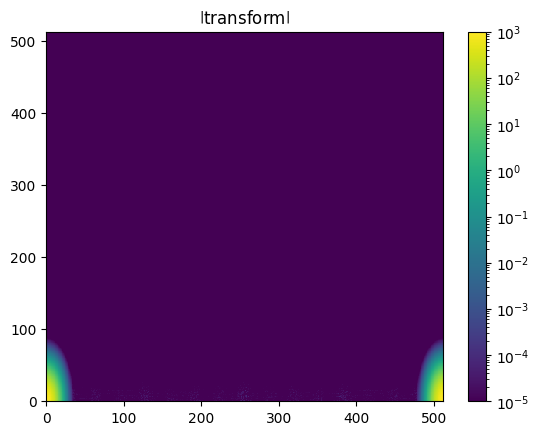

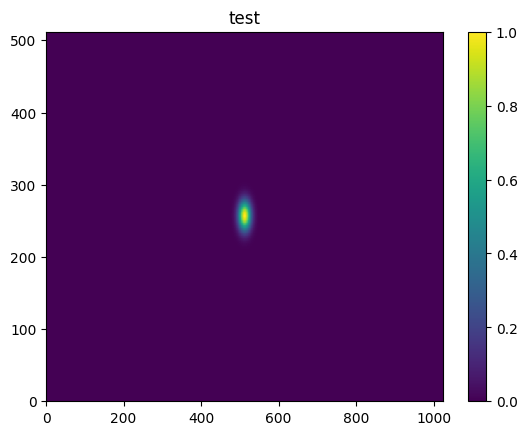

In [3]:
import visxd
visxd.grid( "mpi/data.zdf" )

# visxd.complex_grid2d( "mpi/transform.zdf", part = "abs", norm = "log" )
visxd.complex_grid2d( "mpi/transform.zdf", part = "abs", norm = "log", vmin = 1e-5 )

visxd.grid( "mpi/test.zdf" )

### Poisson solver tests

Tests using the FFT package to solve a simple Poisson equation

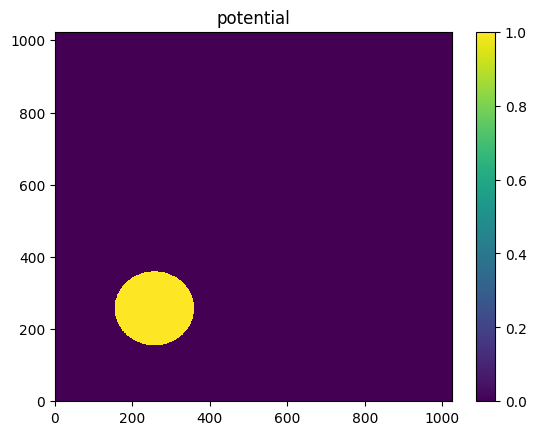

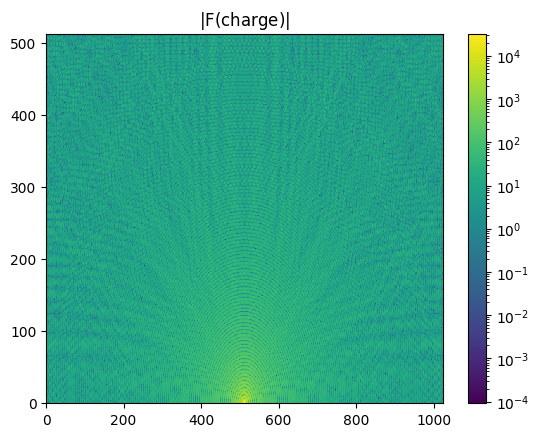

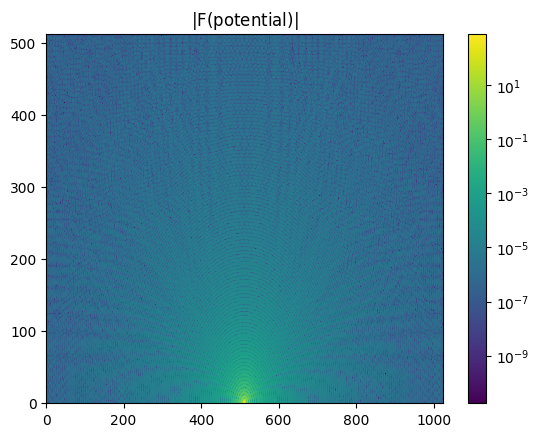

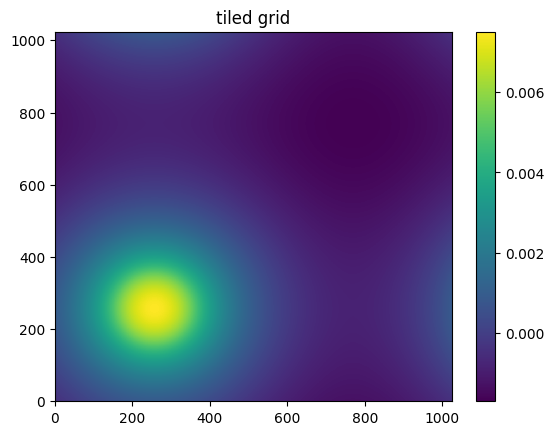

In [3]:
import visxd
import zdf
import matplotlib.colors as colors

visxd.grid2d( "mpi/charge.zdf")

# Shift ky = 0 to vertical center
info = zdf.info( "mpi/charge_k.zdf" )
shiftky = int( info.grid.nx[0] // 2 ) - 1
visxd.complex_grid2d( "mpi/charge_k.zdf", part = 'abs', shift = [shiftky,0], norm = colors.LogNorm())
visxd.complex_grid2d( "mpi/potential_k.zdf", part = 'abs', shift = [shiftky,0], norm = colors.LogNorm() )

visxd.grid2d( "mpi/potential.zdf" )

### Laser test

Injects a laser pulse and propagates it. Tests:

+ `grid::tiled<>::add()` / `grid::vec3_tiled<>::add()` method
+ Laser pulse injection
+ EMF field solver (no current)
+ EMF `.save()` method
+ Timing code

Plotting EMF/Ex-000731.zdf


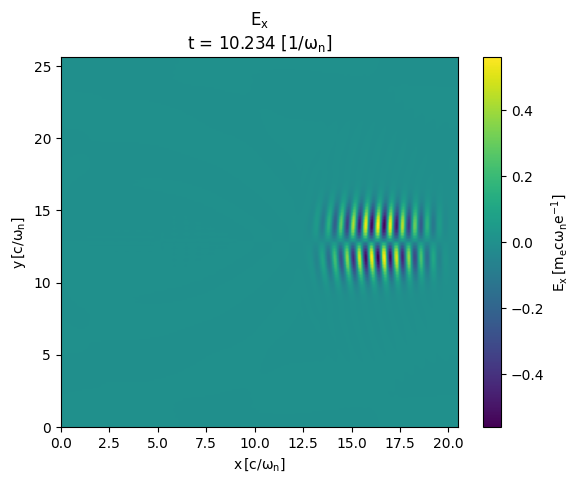

Plotting EMF/Ey-000731.zdf


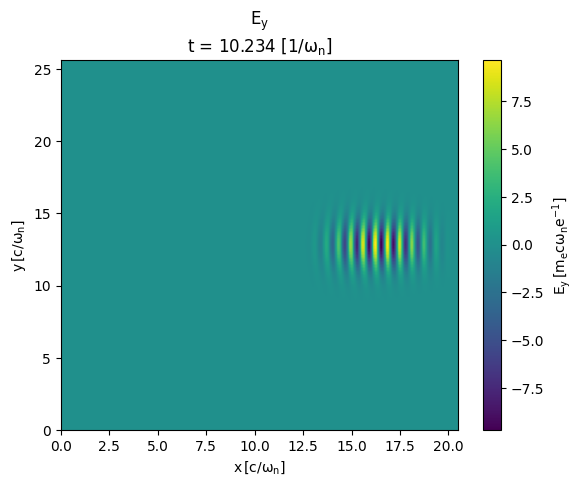

Plotting EMF/Ez-000731.zdf


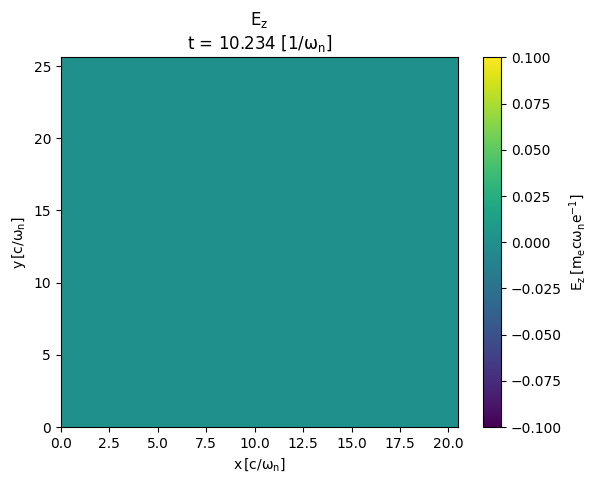

In [66]:
import visxd
import matplotlib.colors as colors

# iter = 0
iter = 731

visxd.plot_data("EMF/Ex", iter )
visxd.plot_data("EMF/Ey", iter )
visxd.plot_data("EMF/Ez", iter )


### Injection test

Sets a density profile and injects it. Tests:

+ Species object creation
+ Charge density deposition
+ Saving particle data (positions in simulation units)
+ Injecting a density profile (uniform / step / slab / sphere )
+ Setting a temperature distribution
+ Phasespace diagnostic

Plotting CHARGE/electrons/electrons-charge-000000.zdf


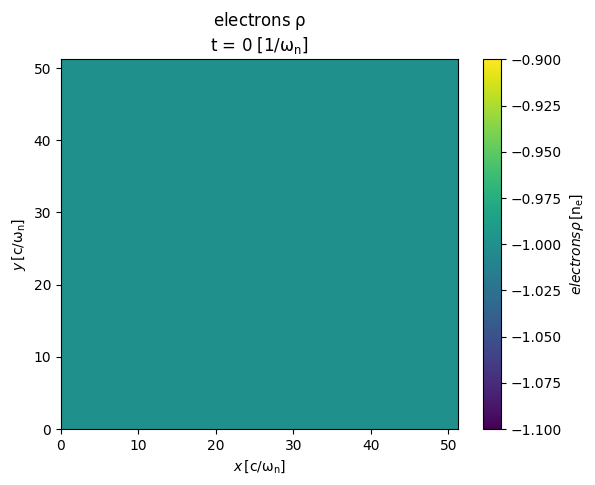

(*error*) file PARTICLES/electrons/particles-electrons-000000.zdf not found.
(*error*) file PARTICLES/electrons/particles-electrons-000000.zdf not found.
(*error*) file PHASESPACE/electrons/electrons-uxuz-000000.zdf not found.


In [5]:
import visxd

visxd.plot_data("CHARGE/electrons/electrons-charge", 0 )
visxd.plot_data("PARTICLES/electrons/particles-electrons", 0 )

visxd.plot_data("PARTICLES/electrons/particles-electrons", 0, qx='ux', qy='uy' )
visxd.plot_data("PHASESPACE/electrons/electrons-uxuz", 0)



### Motion test

Injects a sphere density and moves it for _N_ timesteps. This is performed outside of the simulation, no current is deposited. Tests:

+ `Species::advance()` method
+ `Species::move()` method
+ `Particles::sort()` method

Plotting CHARGE/electrons/electrons-charge-000000.zdf


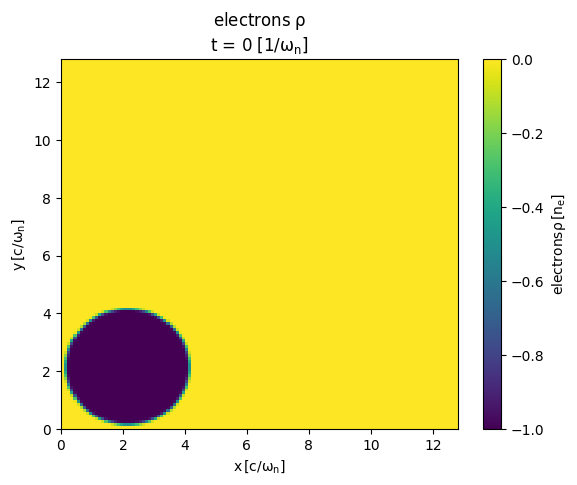

Plotting PARTICLES/electrons/particles-electrons-000000.zdf


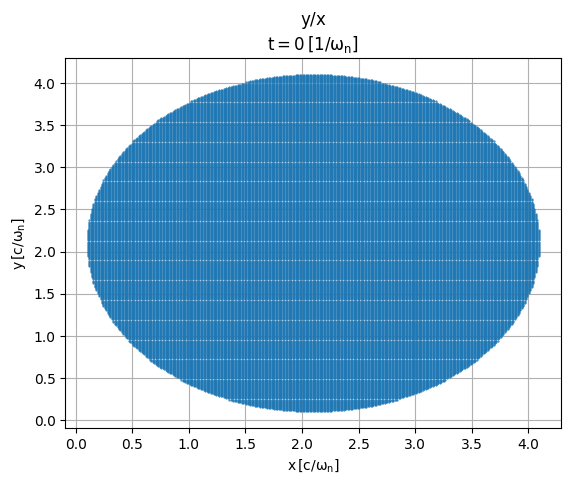

Plotting CHARGE/electrons/electrons-charge-000200.zdf


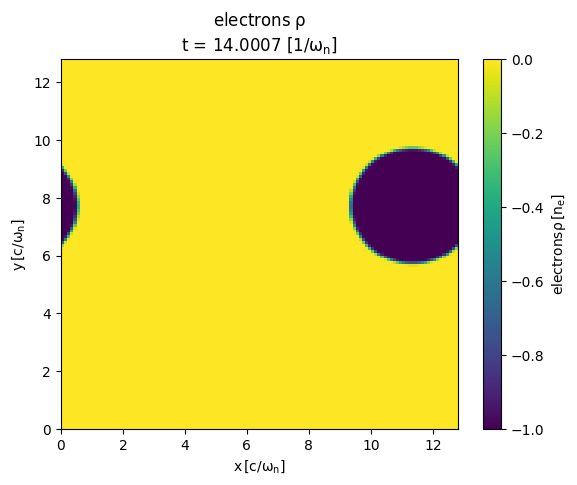

Plotting PARTICLES/electrons/particles-electrons-000200.zdf


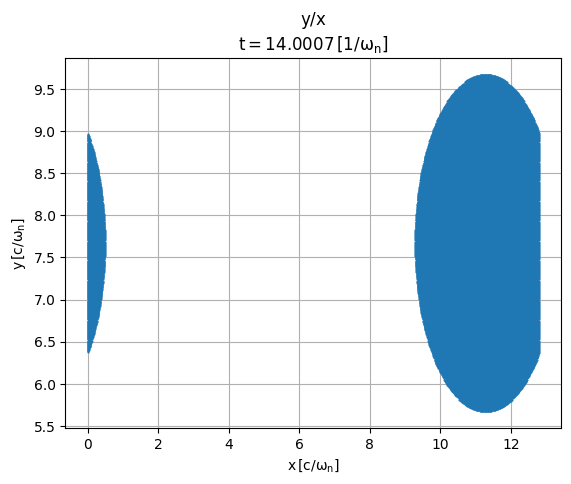

In [10]:
import visxd

# Initial density
visxd.plot_data("CHARGE/electrons/electrons-charge", 0 )
visxd.plot_part("PARTICLES/electrons/particles-electrons", 0 )

# Final density and particles
iter = 200 # 200
visxd.plot_data("CHARGE/electrons/electrons-charge", iter )
visxd.plot_part("PARTICLES/electrons/particles-electrons", iter )

### Current / charge deposit test

Runs 1 iteration of the motion test above and deposits current/charge. Tests:

+ `Species::advance( Current, Charge )` method
+ Current diagnostic routines
+ Charge diagnostic routines

Plotting CURRENT/Jx-000001.zdf


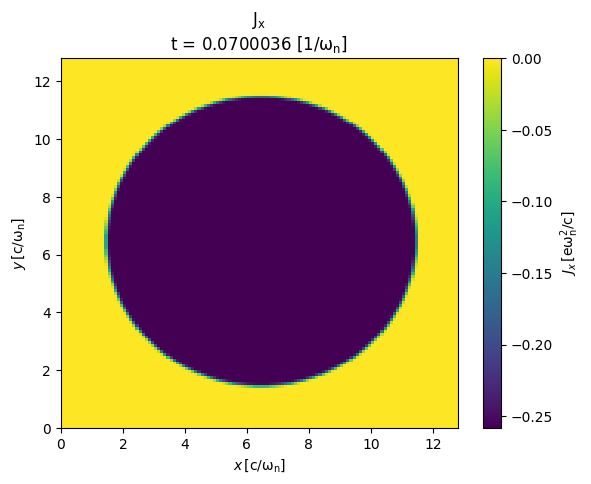

Plotting CHARGE/frho-000001.zdf


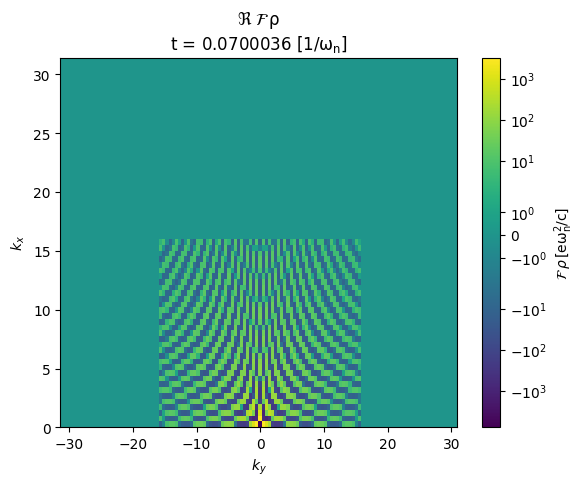

In [1]:
import visxd

iter = 1

visxd.plot_data("CURRENT/Jx", iter )
#visxd.plot_data("CURRENT/Jy", iter )
#visxd.plot_data("CURRENT/Jz", iter )
#visxd.plot_data("CHARGE/rho", iter )

visxd.plot_data("CHARGE/frho", iter,  shift=[64,0], norm = "symlog" )

## Weibel Test

Plotting EMF/B in plane field for iteration 500.


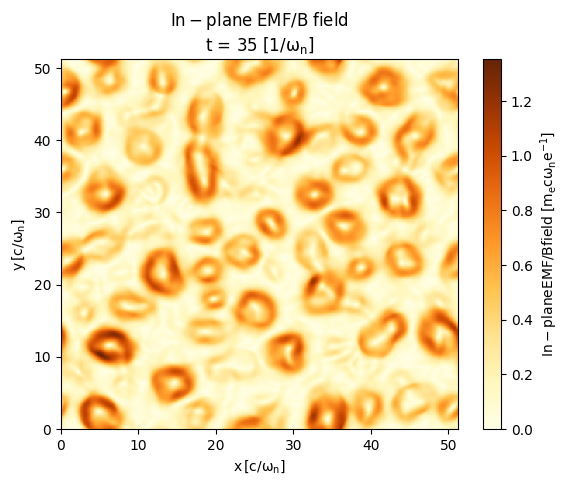

Plotting EMF/B out of plane field for iteration 500.


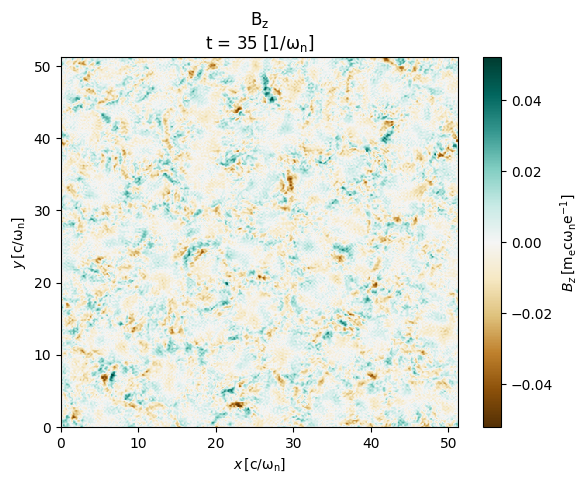

In [1]:
import visxd

iter = 500
# iter = 2143

visxd.plot_vfield2d("EMF/B", iter)

Plotting PHASESPACE/electrons/electrons-uxuy-000500.zdf


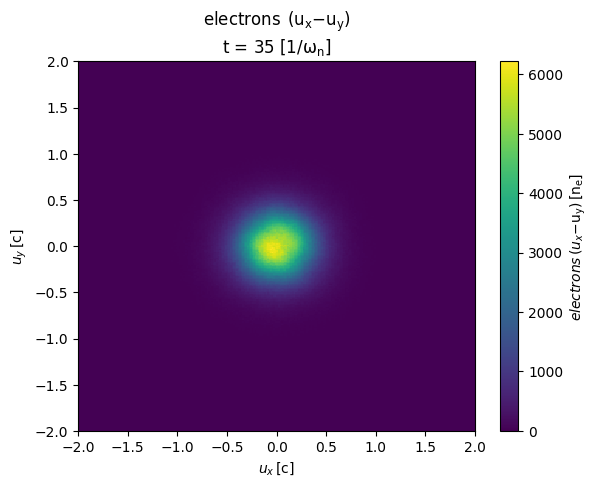

In [3]:
import visxd
visxd.plot_data("PHASESPACE/electrons/electrons-uxuy", 500)